In [28]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def read_jsonl(file_path):
    with open(file_path, 'r') as fr:
        data = [json.loads(line) for line in fr.readlines()]
    return data

In [21]:
overall_results_index = {
        'gsm8k': {},
        'math': {},
        'omnimath': {},
        'olympiadbench': {}
}

for dataset in ['gsm8k', 'math', 'omnimath', 'olympiadbench']:
    for split in ['_error', '_correct']:
        path = f"/data/yefan/VerifySteer/precomputed_results/Qwen3-8B/enable_thinking_False/baseline/processbench/run_0_greedy_maxtokens_8192/{dataset}{split}.jsonl"
        dataframe = read_jsonl(path)
        for item in dataframe:
            overall_results_index[dataset][item['id']] = {}
            overall_results_index[dataset][item['id']][f'baseline'] = {'label': item['label'], 
                                                                     'prediction': item['prediction']}
            
            
for dataset in ['gsm8k', 'math', 'omnimath', 'olympiadbench']:
    for split in ['_error', '_correct']:
        path = f"/data/yefan/VerifySteer/precomputed_results/Qwen3-8B/enable_thinking_False/baseline/processbench_careful_v1/run_0_greedy_maxtokens_8192/{dataset}{split}.jsonl"
        dataframe = read_jsonl(path)
        for item in dataframe:
            overall_results_index[dataset][item['id']][f'prompt_opt'] = {'label': item['label'], 
                                                                     'prediction': item['prediction']}

In [20]:
overall_results_index['olympiadbench']['olympiadbench-999']

{'baseline': {'label': -1, 'prediction': -1},
 'prompt_opt': {'label': -1, 'prediction': -1}}

In [33]:
baseline_results = {}
for method in ['baseline', 'prompt_opt']:
    baseline_results[method] = {}
    print('method', method)
    for dataset in ['gsm8k',
                    'math',
                    'olympiadbench', 
                    'omnimath']:
        error_count = 0
        error_correct_count = 0
        correct_count = 0
        correct_correct_count = 0
        for key in overall_results_index[dataset]:
            selected_item = overall_results_index[dataset][key][method]
            if selected_item['label'] > -1:
                error_count += 1
                if selected_item['label'] == selected_item['prediction']:
                    error_correct_count += 1
            else:
                correct_count += 1
                if selected_item['label'] == selected_item['prediction']:
                    correct_correct_count += 1
                    
        tnr = (error_correct_count / error_count) * 100
        tpr = (correct_correct_count / correct_count) * 100
        f1 = 2 * tpr * tnr / (tpr + tnr)
        print(dataset, f'tnr: {tnr:.1f}, tpr: {tpr:.1f}, f1: {f1:.1f}')

        baseline_results[method][dataset] = {
                        'error_acc': tnr,
                        'correct_acc': tpr,
                        'f1': f1
                    }
    print('--------------------')


method baseline
gsm8k tnr: 54.6, tpr: 96.4, f1: 69.7
math tnr: 58.4, tpr: 83.0, f1: 68.6
olympiadbench tnr: 54.0, tpr: 76.1, f1: 63.2
omnimath tnr: 53.8, tpr: 73.4, f1: 62.1
--------------------
method prompt_opt
gsm8k tnr: 58.5, tpr: 94.3, f1: 72.2
math tnr: 66.8, tpr: 85.0, f1: 74.8
olympiadbench tnr: 58.4, tpr: 77.9, f1: 66.7
omnimath tnr: 58.6, tpr: 75.5, f1: 66.0
--------------------


In [23]:
for direction in ['increasing_strictness', 'decreasing_strictness']:
    for dataset, scale, beta in [
                                ('gsm8k', 2.0, 0.0),
                                ('math', 2.0, 0.0),
                                ('olympiadbench', 1.0, 0.0),
                                ('omnimath', 1.0, 0.0)
                                ]:
        
        for split in ['_error', '_correct']:
            path = f"/data/yefan/VerifySteer/precomputed_results/Qwen3-8B/gated_norm_direct_cosine_mask/" + \
            f"{dataset}/{direction}/enable_thinking_False/scale_{scale}_L22-23_beta{beta}/" + \
            f"processbench_careful_v1/run_0_greedy_maxtokens_8192/{dataset}{split}.jsonl"
            
            dataframe = read_jsonl(path)
            
            for item in dataframe:
                overall_results_index[dataset][item['id']][direction] = {'label': item['label'], 
                                                                    'prediction': item['prediction']}

            

In [25]:
for method in ['increasing_strictness', 'decreasing_strictness']:
    print('method', method)
    for dataset in ['gsm8k',
                    'math',
                    'olympiadbench', 
                    'omnimath']:
        error_count = 0
        error_correct_count = 0
        correct_count = 0
        correct_correct_count = 0
        for key in overall_results_index[dataset]:
            selected_item = overall_results_index[dataset][key][method]
            if selected_item['label'] > -1:
                error_count += 1
                if selected_item['label'] == selected_item['prediction']:
                    error_correct_count += 1
            else:
                correct_count += 1
                if selected_item['label'] == selected_item['prediction']:
                    correct_correct_count += 1
                    
        tnr = (error_correct_count / error_count) * 100
        tpr = (correct_correct_count / correct_count) * 100
        f1 = 2 * tpr * tnr / (tpr + tnr)
        print(dataset, f'tnr: {tnr:.1f}, tpr: {tpr:.1f}, f1: {f1:.1f}')
    
    print('--------------------')

method increasing_strictness
gsm8k tnr: 62.8, tpr: 91.7, f1: 74.6
math tnr: 69.2, tpr: 83.5, f1: 75.7
olympiadbench tnr: 60.2, tpr: 73.5, f1: 66.2
omnimath tnr: 61.5, tpr: 71.8, f1: 66.3
--------------------
method decreasing_strictness
gsm8k tnr: 61.4, tpr: 95.3, f1: 74.7
math tnr: 66.5, tpr: 87.9, f1: 75.7
olympiadbench tnr: 58.2, tpr: 78.8, f1: 67.0
omnimath tnr: 59.4, tpr: 76.3, f1: 66.8
--------------------


Hyper sweep values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Routing: increasing_strictness / prompt_opt
Selected threshold tau = 0.5


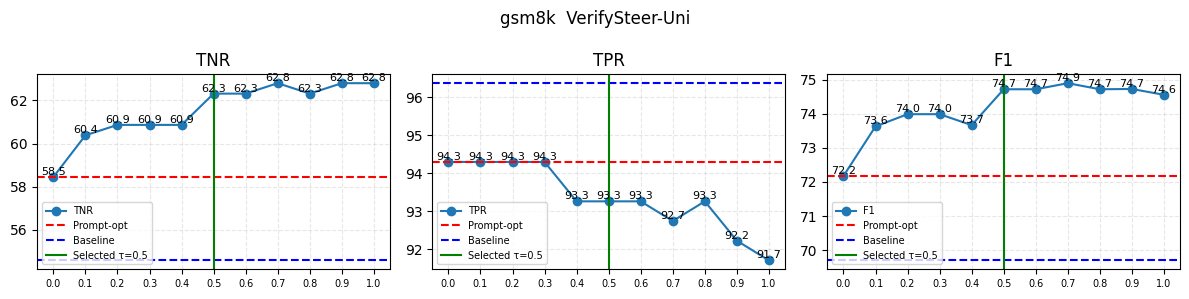

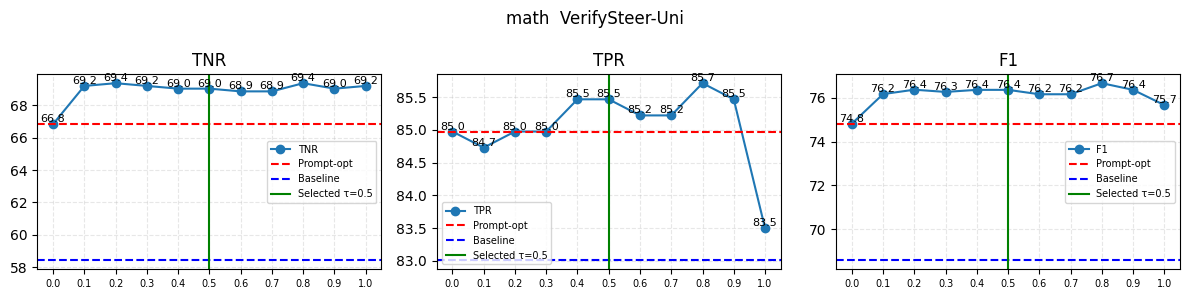

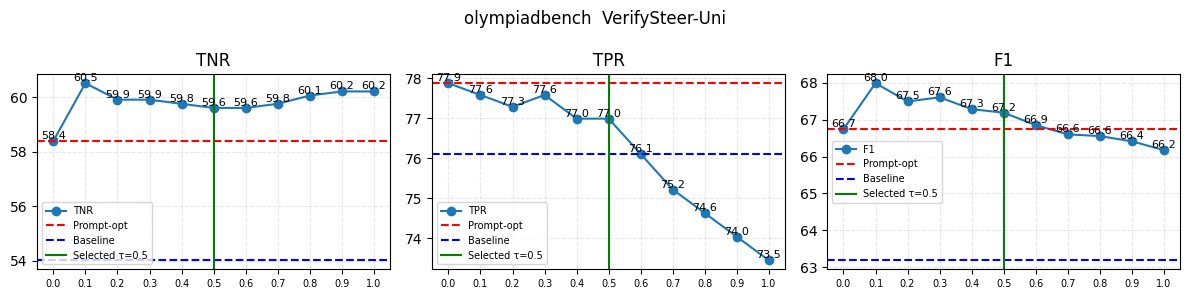

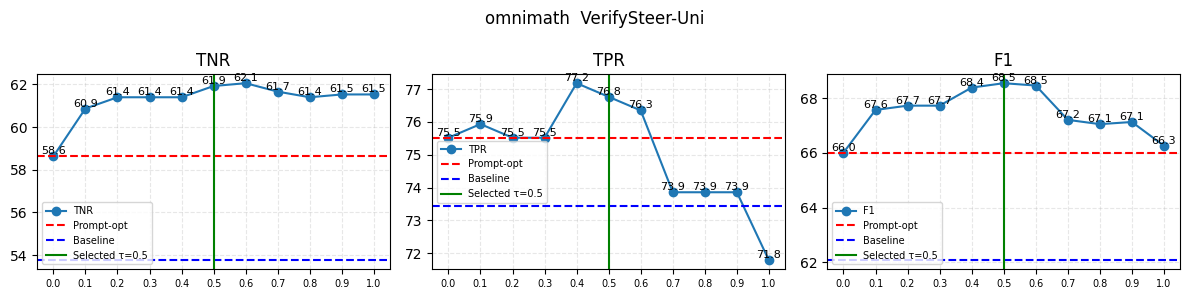

In [38]:
hyper_sweep = np.round(np.arange(0, 1.1, 0.1), 2)
tau = 0.5  # selected threshold

strict_key  = 'increasing_strictness'   # used when predicted_prob <= threshold
lenient_key = 'prompt_opt'     # used otherwise
# e.g. strict_key='increasing_strictness', lenient_key='decreasing_strictness'

print("Hyper sweep values:", hyper_sweep)
print(f"Routing: {strict_key} / {lenient_key}")
print(f"Selected threshold tau = {tau}")

hyper_results = {}
for dataset in ['gsm8k', 'math', 'olympiadbench', 'omnimath']:
    base_path = (f"/data/yefan/VerifySteer/verify_mlp_probe_weights/processbench/Qwen3-8B/"
                 f"verify_processbench_careful_v1_all_generated_avg/"
                 f"layer23_hid1024_3layer_bs32_lr1e-05_wd1e-02_epoch300/{dataset}")
    pred_path = f"{base_path}/layer_23_predictions.json"
    pred_dataframe = json.load(open(pred_path))

    tnr_lst, tpr_lst, f1_lst = [], [], []
    for threshold in hyper_sweep:
        correct_count = 0
        correct_correct_count = 0
        incorrect_count = 0
        incorrect_correct_count = 0
        for item in pred_dataframe:
            if item['predicted_prob'] <= threshold:
                prediction = overall_results_index[dataset][item['id']][strict_key]['prediction']
            else:
                prediction = overall_results_index[dataset][item['id']][lenient_key]['prediction']

            label = overall_results_index[dataset][item['id']]['baseline']['label']

            if label == -1:
                correct_count += 1
                if prediction == label:
                    correct_correct_count += 1
            else:
                incorrect_count += 1
                if prediction == label:
                    incorrect_correct_count += 1

        assert correct_count + incorrect_count == len(pred_dataframe)
        tpr = correct_correct_count / correct_count
        tnr = incorrect_correct_count / incorrect_count
        f1 = 2 * tpr * tnr / (tpr + tnr) if (tpr + tnr) > 0 else 0.0
        tnr_lst.append(tnr); tpr_lst.append(tpr); f1_lst.append(f1)

    for h_i, h_v in enumerate(hyper_sweep):
        hyper_results.setdefault(f'h_v_{h_v}', {})[dataset] = {
            'f1':  f1_lst[h_i]  * 100,
            'tpr': tpr_lst[h_i] * 100,
            'tnr': tnr_lst[h_i] * 100,
        }

    plt.figure(figsize=(12, 3))
    plt.suptitle(f"{dataset}  VerifySteer-Uni")

    # Plot TNR
    plt.subplot(1, 3, 1)
    plt.title('TNR')
    plt.plot(hyper_sweep, [x*100 for x in tnr_lst], marker='o', label='TNR')
    for x, y in zip(hyper_sweep, [v*100 for v in tnr_lst]):
        plt.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=8)
    plt.axhline(y=baseline_results['prompt_opt'][dataset]['error_acc'], color='red', linestyle='--', label='Prompt-opt')
    plt.axhline(y=baseline_results['baseline'][dataset]['error_acc'], color='blue', linestyle='--', label='Baseline')
    plt.axvline(x=tau, color='green', linestyle='-', label=f'Selected τ={tau:.1f}')
    plt.xticks(hyper_sweep, fontsize=7)
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(fontsize=7)

    # Plot TPR
    plt.subplot(1, 3, 2)
    plt.title('TPR')
    plt.plot(hyper_sweep, [x*100 for x in tpr_lst], marker='o', label='TPR')
    for x, y in zip(hyper_sweep, [v*100 for v in tpr_lst]):
        plt.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=8)
    plt.axhline(y=baseline_results['prompt_opt'][dataset]['correct_acc'], color='red', linestyle='--', label='Prompt-opt')
    plt.axhline(y=baseline_results['baseline'][dataset]['correct_acc'], color='blue', linestyle='--', label='Baseline')
    plt.axvline(x=tau, color='green', linestyle='-', label=f'Selected τ={tau:.1f}')
    plt.xticks(hyper_sweep, fontsize=7)
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(fontsize=7)

    # Plot F1
    plt.subplot(1, 3, 3)
    plt.title('F1')
    plt.plot(hyper_sweep, [x*100 for x in f1_lst], marker='o', label='F1')
    for x, y in zip(hyper_sweep, [v*100 for v in f1_lst]):
        plt.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=8)
    plt.axhline(y=baseline_results['prompt_opt'][dataset]['f1'], color='red', linestyle='--', label='Prompt-opt')
    plt.axhline(y=baseline_results['baseline'][dataset]['f1'], color='blue', linestyle='--', label='Baseline')
    plt.axvline(x=tau, color='green', linestyle='-', label=f'Selected τ={tau:.1f}')
    plt.xticks(hyper_sweep, fontsize=7)
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(fontsize=7)
    
    plt.tight_layout()

Hyper sweep values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Routing: increasing_strictness / decreasing_strictness
Selected threshold tau = 0.5


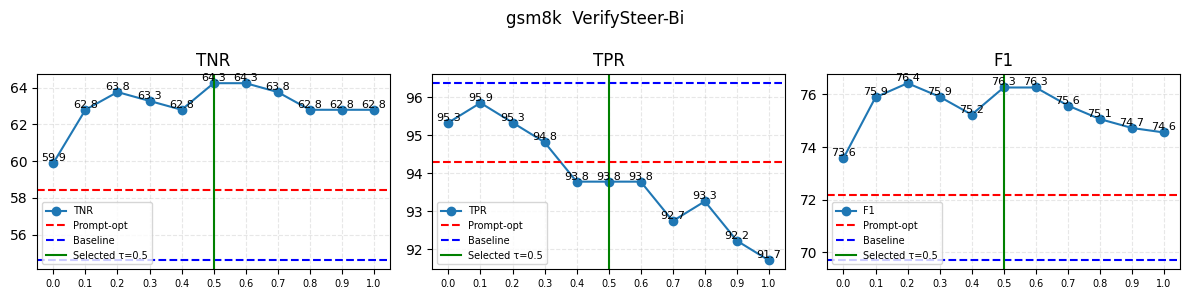

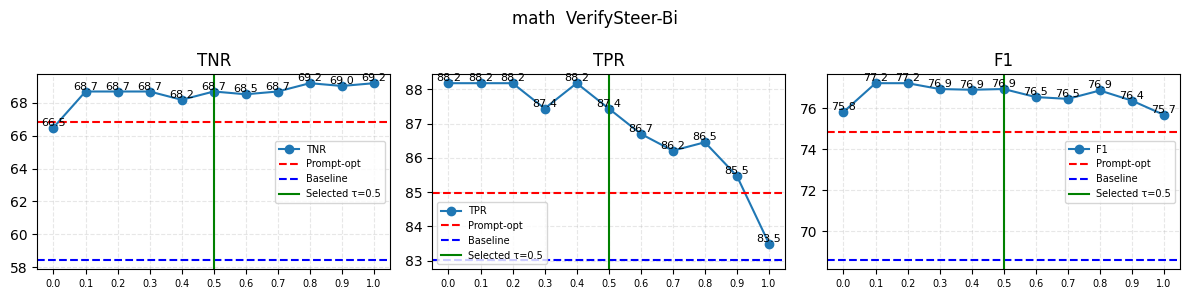

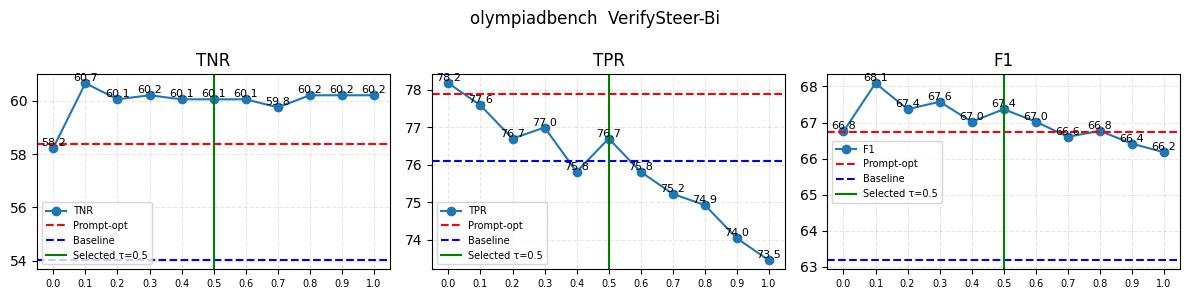

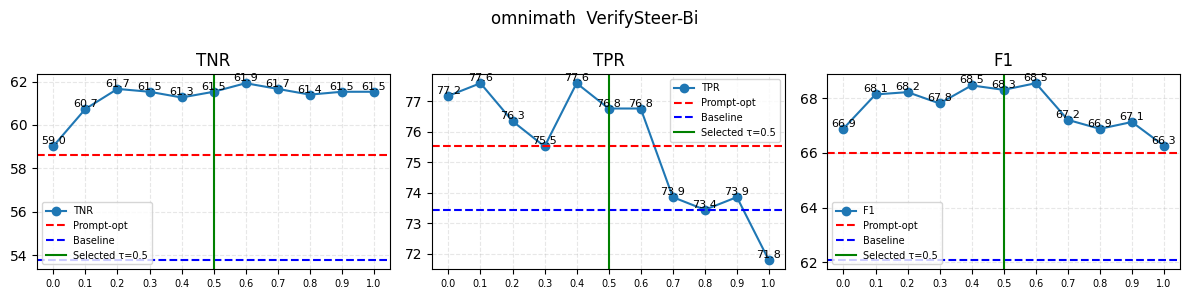

In [40]:
hyper_sweep = np.round(np.arange(0, 1.1, 0.1), 2)
tau = 0.5  # selected threshold
delta = 0.1
strict_key  = 'increasing_strictness'   # used when predicted_prob <= threshold
lenient_key = 'decreasing_strictness'     # used otherwise
# e.g. strict_key='increasing_strictness', lenient_key='decreasing_strictness'

print("Hyper sweep values:", hyper_sweep)
print(f"Routing: {strict_key} / {lenient_key}")
print(f"Selected threshold tau = {tau}")

hyper_results = {}
for dataset in ['gsm8k', 'math', 'olympiadbench', 'omnimath']:
    base_path = (f"/data/yefan/VerifySteer/verify_mlp_probe_weights/processbench/Qwen3-8B/"
                 f"verify_processbench_careful_v1_all_generated_avg/"
                 f"layer23_hid1024_3layer_bs32_lr1e-05_wd1e-02_epoch300/{dataset}")
    pred_path = f"{base_path}/layer_23_predictions.json"
    pred_dataframe = json.load(open(pred_path))

    tnr_lst, tpr_lst, f1_lst = [], [], []
    for threshold in hyper_sweep:
        correct_count = 0
        correct_correct_count = 0
        incorrect_count = 0
        incorrect_correct_count = 0
        for item in pred_dataframe:
            if item['predicted_prob'] <= threshold:
                prediction = overall_results_index[dataset][item['id']][strict_key]['prediction']
            elif item['predicted_prob'] >= threshold + delta:
                prediction = overall_results_index[dataset][item['id']][lenient_key]['prediction']
            else:
                prediction = overall_results_index[dataset][item['id']]['prompt_opt']['prediction']

            label = overall_results_index[dataset][item['id']]['baseline']['label']

            if label == -1:
                correct_count += 1
                if prediction == label:
                    correct_correct_count += 1
            else:
                incorrect_count += 1
                if prediction == label:
                    incorrect_correct_count += 1

        assert correct_count + incorrect_count == len(pred_dataframe)
        tpr = correct_correct_count / correct_count
        tnr = incorrect_correct_count / incorrect_count
        f1 = 2 * tpr * tnr / (tpr + tnr) if (tpr + tnr) > 0 else 0.0
        tnr_lst.append(tnr); tpr_lst.append(tpr); f1_lst.append(f1)

    for h_i, h_v in enumerate(hyper_sweep):
        hyper_results.setdefault(f'h_v_{h_v}', {})[dataset] = {
            'f1':  f1_lst[h_i]  * 100,
            'tpr': tpr_lst[h_i] * 100,
            'tnr': tnr_lst[h_i] * 100,
        }

    plt.figure(figsize=(12, 3))
    plt.suptitle(f"{dataset}  VerifySteer-Bi")

    # Plot TNR
    plt.subplot(1, 3, 1)
    plt.title('TNR')
    plt.plot(hyper_sweep, [x*100 for x in tnr_lst], marker='o', label='TNR')
    for x, y in zip(hyper_sweep, [v*100 for v in tnr_lst]):
        plt.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=8)
    plt.axhline(y=baseline_results['prompt_opt'][dataset]['error_acc'], color='red', linestyle='--', label='Prompt-opt')
    plt.axhline(y=baseline_results['baseline'][dataset]['error_acc'], color='blue', linestyle='--', label='Baseline')
    plt.axvline(x=tau, color='green', linestyle='-', label=f'Selected τ={tau:.1f}')
    plt.xticks(hyper_sweep, fontsize=7)
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(fontsize=7)

    # Plot TPR
    plt.subplot(1, 3, 2)
    plt.title('TPR')
    plt.plot(hyper_sweep, [x*100 for x in tpr_lst], marker='o', label='TPR')
    for x, y in zip(hyper_sweep, [v*100 for v in tpr_lst]):
        plt.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=8)
    plt.axhline(y=baseline_results['prompt_opt'][dataset]['correct_acc'], color='red', linestyle='--', label='Prompt-opt')
    plt.axhline(y=baseline_results['baseline'][dataset]['correct_acc'], color='blue', linestyle='--', label='Baseline')
    plt.axvline(x=tau, color='green', linestyle='-', label=f'Selected τ={tau:.1f}')
    plt.xticks(hyper_sweep, fontsize=7)
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(fontsize=7)

    # Plot F1
    plt.subplot(1, 3, 3)
    plt.title('F1')
    plt.plot(hyper_sweep, [x*100 for x in f1_lst], marker='o', label='F1')
    for x, y in zip(hyper_sweep, [v*100 for v in f1_lst]):
        plt.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=8)
    plt.axhline(y=baseline_results['prompt_opt'][dataset]['f1'], color='red', linestyle='--', label='Prompt-opt')
    plt.axhline(y=baseline_results['baseline'][dataset]['f1'], color='blue', linestyle='--', label='Baseline')
    plt.axvline(x=tau, color='green', linestyle='-', label=f'Selected τ={tau:.1f}')
    plt.xticks(hyper_sweep, fontsize=7)
    plt.grid(linestyle='--', alpha=0.3)
    plt.legend(fontsize=7)
    
    plt.tight_layout()